# Fake News Detection Using NLP

## Importing Libraries

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rawat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Dataset

In [3]:
fake_df = pd.read_csv('data/Fake.csv')
true_df = pd.read_csv('data/True.csv')

print(fake_df.shape)
print(true_df.shape)

(23481, 4)
(21417, 4)


In [4]:
fake_df['label'] = 0 # Fake
true_df['label'] = 1 # Real

In [5]:
df = pd.concat([fake_df,true_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [6]:
df.info()
df.isnull().sum()
df['label'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 1.7 MB


label
0    23481
1    21417
Name: count, dtype: int64

In [7]:
df['text'][0]

'21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OUR WORK BY SUBSCRIBING &

---
- The dataset contains approximately ~44,800 news articles, combining both fake and real news samples.
- The dataset is balanced, with a nearly equal distribution of fake(0) and real (1) labels, ensuring unbiased model training.
- No missing values were found across any columns, which shows high data quality
- The textual content is realistic and detailed, making classification non-trivial and suitable for NLP modeling.
---

## Text Preprocessing

In [8]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

In [9]:
df['content'] = df['title'] + ' ' + df['text']
df['content'] = df['content'].apply(preprocess_text)

In [10]:
df['content'].iloc[0]

'ben stein call th circuit court commit coup tat constitut st centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear tv show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judgement th circuit court washington state coup tat execut branch constitut stein went call judg seattl polit puppet judiciari polit pawn watch interview complet statement note stark contrast rhetor leftist media pundit neglect note court ever block presidenti order immigr past discuss legal efficaci halt actual text execut order read trump news st centuri wire trump filessupport work subscrib becom member wire tv'

---
- Combined title and article text into a single feature(content) to capture both headline cues and contextual information.
- Applied multiple preprocessing steps:
    - Lowercasing for uniformity
    - Removal of punctuation, numbers and special characters
    - Tokenization (splitting text into words)
    - Stopword removal to eliminate common non-informative words
    - Stemming to reduce words to root forms
- Stemming resulted in reduced readability (e.g., 'policy' -> 'polici'), but improved:
    - Model generalization
    - Vocabulary consistency
---

## Train-test Split

In [11]:
X = df['content']
y = df['label']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42
)

## TF-IDF Feature Engineering

In [ ]:
vectorizer_v1 = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer_v1.fit_transform(X_train)
X_test_tfidf = vectorizer_v1.transform(X_test)

In [14]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(35918, 5000)
(8980, 5000)


In [15]:
feature_names = vectorizer_v1.get_feature_names_out()
print(feature_names[:20])

['aaron' 'abadi' 'abandon' 'abba' 'abbott' 'abc' 'abdel' 'abdullah' 'abe'
 'abedin' 'abid' 'abil' 'abl' 'aboard' 'abolish' 'abort' 'abroad'
 'abruptli' 'absenc' 'absolut']


---
- Used 5000 most important features (words)
- Converted text into numerical vectors representing importance
- TF-IDF effectively captures importance of words rather than just frequency
---

## Logistic Regression (Baseline Model)

In [16]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [21]:
print('Accuracy:', accuracy_score(y_test, y_pred_lr))
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr))
print('ROC-AUC:', roc_auc_score(y_test, lr_model.predict_proba(X_test_tfidf)[:,1]))

Accuracy: 0.9851893095768374

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.98      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

ROC-AUC: 0.9985012206824884


---
- Achieved ~98% accuracy in the baseline model
- ROC-AUC is ~99.8%
---

## Naive Bayes Model

In [19]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [20]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [23]:
print('Accuracy:', accuracy_score(y_test, y_pred_nb))
print('\nClassification Report:\n', classification_report(y_test, y_pred_nb))
print('ROC-AUC:', roc_auc_score(y_test, nb_model.predict_proba(X_test_tfidf)[:,1]))

Accuracy: 0.9289532293986636

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      4710
           1       0.93      0.92      0.92      4270

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980

ROC-AUC: 0.9786747017905


---
- Achieved ~92% accuracy
- Lower performance than Logistic Regression due to independence assumption
- Logistic Regression outperformed Naive Bayes because:
    - It considers relationships between features
    - It handles correlated words better
- Naive Bayes is faster but less expressive for text data
---

## Model Tuning

In [24]:
vectorizer_v2 = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.7
)

---
### Improved TF-IDF:
- Added bi-grams (ngram_range -> (1,2))
- Applied:
    - min_df=5 --> removed rare words
    - max_df=0.7 --> removed overly common words
- Bi-grams helped capture contextual phrases (e.g., 'fake news')
- Feature space became more meaningful after filtering noise
---

In [25]:
X_train_tfidf_v2 = vectorizer_v2.fit_transform(X_train)
X_test_tfidf_v2 = vectorizer_v2.transform(X_test)

In [26]:
lr_model_v2 = LogisticRegression()
lr_model_v2.fit(X_train_tfidf_v2, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
y_pred_v2 = lr_model_v2.predict(X_test_tfidf_v2)

In [28]:
print('Accuracy:', accuracy_score(y_test, y_pred_v2))
print('ROC-AUC:', roc_auc_score(y_test, lr_model_v2.predict_proba(X_test_tfidf_v2)[:,1]))

Accuracy: 0.987305122494432
ROC-AUC: 0.9989283849699429


---
- Improved accuracy to ~98.7%
- ROC-AUC reached ~99.8% (slightly higher than baseline)

In [29]:
print('Baseline Accuracy:', accuracy_score(y_test, y_pred_lr))
print('Improved Accuracy:', accuracy_score(y_test, y_pred_v2))


Baseline Accuracy: 0.9851893095768374
Improved Accuracy: 0.987305122494432


---
- Incorporating bi-grams led to slight performance improvement
- Model captured phrase-level semantics, not just individual words
- Feature filtering reduced noise and improved feature quality
---
Trade-off Observed:
- Accuracy improvement: +0.3%
- Training time increased from ~6s to ~26s

## Feature Importance

In [31]:
feature_names = vectorizer_v2.get_feature_names_out()
coefficients = lr_model_v2.coef_[0]

top_fake = np.argsort(coefficients)[:20]
top_real = np.argsort(coefficients)[-20:]

In [32]:
print('Top words for fake news:\n')
for i in top_fake:
    print(feature_names[i])

Top words for fake news:

via
video
us
imag
read
hillari
presid trump
gop
featur imag
featur
mr
obama
america
watch
wire
imag via
even
com
american
getti


In [33]:
print('\nTop words for real news:\n')
for i in reversed(top_real):
    print(feature_names[i])


Top words for real news:

reuter
washington reuter
wednesday
presid donald
washington
tuesday
thursday
reuter presid
friday
said statement
monday
nov
spokesman
minist
statement
trump said
presidenti
presid barack
republican
told reuter


---
Fake News Indicators:
- Words like: video, read, imag, hillari
    - suggest informal tone,
    - social media-style content
    - sensational framing

Real News Indicators:
- Words like reuter, washington, tuesday
    - suggest formal journalism,
    - source attribution,
    - Temporal context
- Model is learning writing style and credibility signals, not just keywords

- Words like 'Reuters' strongly influence classification, and indicates source-based bias in dataset
- Model may not generalize well to unseen news source and independent journalism platforms
---


## Error Analysis (Confusion Matrix)

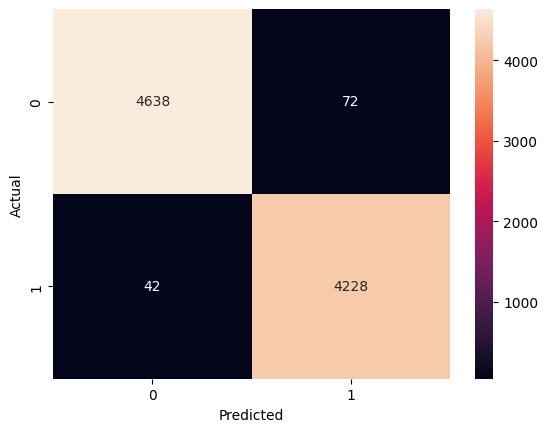

In [36]:
cm = confusion_matrix(y_test, y_pred_v2)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- False Positives (Fake -> Real): 72
- False Negatives (Real -> Fake): 42

Observations:
- Model is slightly biased towards predicting news as real
- Fake news that mimics real journalistic style is harder to detect
- False positives are more dangerous in real-world scenarios (fake news being classified as real)

## Key Insights
- NLP preprocessing plays a crucial role in model performance
- TF-IDF is a powerful baseline technique for text classification
- Logistic Regression is highly effective for high-dimensional sparse data
- Context (via n_grams) improves classification quality
- Evaluation beyond accuracy (ROC-AUC, confusion matrix) provides deeper understanding